# 🖼️ Step 18: Image Basics in Python

**Goal:** Understand how AI "sees" images — pixels, RGB, arrays, and basic editing.

| Part | What You'll Learn |
|------|-------------------|
| **Part 1** | What IS an image? (Pixels, RGB, arrays) |
| **Part 2** | Load, inspect, and display images with Pillow |
| **Part 3** | Pixel manipulation — edit individual pixels |
| **Part 4** | Color channels — R, G, B separated |
| **Part 5** | Basic transformations — resize, rotate, crop, flip |
| **Part 6** | Filters & effects — blur, sharpen, edge detection |
| **Part 7** | Drawing on images — text, shapes, overlays |
| **Part 8** | Build a mini image editor (all tools combined) |

### Why This Matters for AI
- Neural networks see images as **number arrays** (just like we see them here)
- Understanding pixels → understanding what CNNs process
- Image editing operations are the **building blocks** of AI image generation

In [1]:
from PIL import Image, ImageFilter, ImageEnhance, ImageDraw, ImageFont
import numpy as np
import matplotlib.pyplot as plt
import os

# Display images inline in the notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

print(f"✅ Libraries loaded!")
print(f"   Pillow (PIL) — image loading, editing, filters")
print(f"   NumPy — images as number arrays")
print(f"   Matplotlib — display images in notebook")

✅ Libraries loaded!
   Pillow (PIL) — image loading, editing, filters
   NumPy — images as number arrays
   Matplotlib — display images in notebook


---
## Part 1: What IS an Image?

An image is just a **grid of colored dots** called **pixels**.

Each pixel has 3 numbers: **(Red, Green, Blue)** — values from 0 to 255.

```
┌──────────────────────────────┐
│ (255,0,0)  (0,255,0)  ...   │   ← Row 0
│ (0,0,255)  (255,255,0) ...  │   ← Row 1
│    ...        ...      ...  │
└──────────────────────────────┘
    Col 0      Col 1
```

| Color | RGB Value |
|-------|-----------|
| Red | (255, 0, 0) |
| Green | (0, 255, 0) |
| Blue | (0, 0, 255) |
| White | (255, 255, 255) |
| Black | (0, 0, 0) |
| Yellow | (255, 255, 0) |

So a 1920×1080 image = **1920 × 1080 × 3 = 6,220,800 numbers!**

Let's create an image from scratch to see this:

Image array shape: (200, 200, 3)
  200 rows (height)
  200 columns (width)
  3 channels (R, G, B)
  Total numbers: 120,000
  Data type: uint8 (0-255)


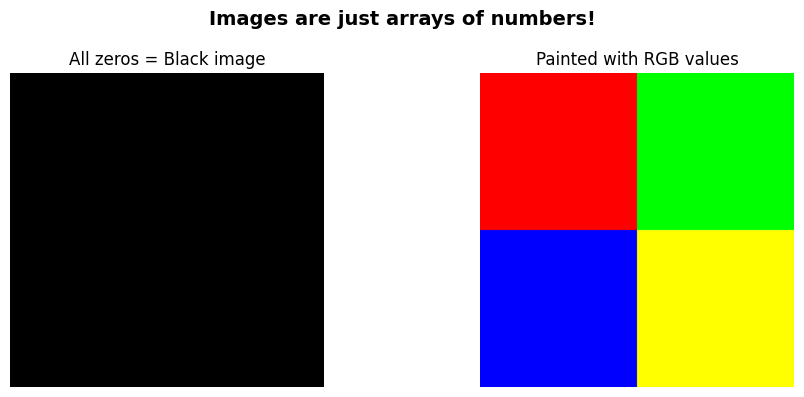


Pixel at (50, 50) — top-left red region:   [255   0   0]
Pixel at (50, 150) — top-right green region: [  0 255   0]
Pixel at (150, 50) — bottom-left blue region: [  0   0 255]
Pixel at (150, 150) — bottom-right yellow:    [255 255   0]


In [2]:
# ---- Create an image FROM SCRATCH using just numbers ----

# A 200x200 image = array of shape (200, 200, 3)
# 200 rows × 200 columns × 3 color channels (R, G, B)
width, height = 200, 200
pixels = np.zeros((height, width, 3), dtype=np.uint8)  # all black

print(f"Image array shape: {pixels.shape}")
print(f"  {pixels.shape[0]} rows (height)")
print(f"  {pixels.shape[1]} columns (width)")
print(f"  {pixels.shape[2]} channels (R, G, B)")
print(f"  Total numbers: {pixels.size:,}")
print(f"  Data type: {pixels.dtype} (0-255)")

# Paint different colored regions
pixels[0:100, 0:100]   = [255, 0, 0]     # Top-left: RED
pixels[0:100, 100:200] = [0, 255, 0]     # Top-right: GREEN
pixels[100:200, 0:100] = [0, 0, 255]     # Bottom-left: BLUE
pixels[100:200, 100:200] = [255, 255, 0] # Bottom-right: YELLOW

# Convert numpy array → PIL Image
img_from_array = Image.fromarray(pixels)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Show the all-black before painting
axes[0].imshow(np.zeros((200, 200, 3), dtype=np.uint8))
axes[0].set_title('All zeros = Black image')
axes[0].axis('off')

# Show the painted image
axes[1].imshow(img_from_array)
axes[1].set_title('Painted with RGB values')
axes[1].axis('off')

plt.suptitle('Images are just arrays of numbers!', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Show actual pixel values
print(f"\nPixel at (50, 50) — top-left red region:   {pixels[50, 50]}")
print(f"Pixel at (50, 150) — top-right green region: {pixels[50, 150]}")
print(f"Pixel at (150, 50) — bottom-left blue region: {pixels[150, 50]}")
print(f"Pixel at (150, 150) — bottom-right yellow:    {pixels[150, 150]}")

---
## Part 2: Load, Inspect, and Display Images

Let's create a realistic sample image with gradients and patterns,  
then learn how to inspect every detail.

✅ Sample image saved to images/sample_scene.png

📋 Image Properties:
   Size:       (400, 300) (width × height)
   Mode:       RGB (RGB = 3 channels)
   Format:     PNG
   Total pixels: 120,000
   Total numbers: 360,000 (pixels × 3 channels)

📊 As NumPy array:
   Shape: (300, 400, 3) — (height, width, channels)
   Min value: 15, Max value: 255
   Memory: 351.6 KB


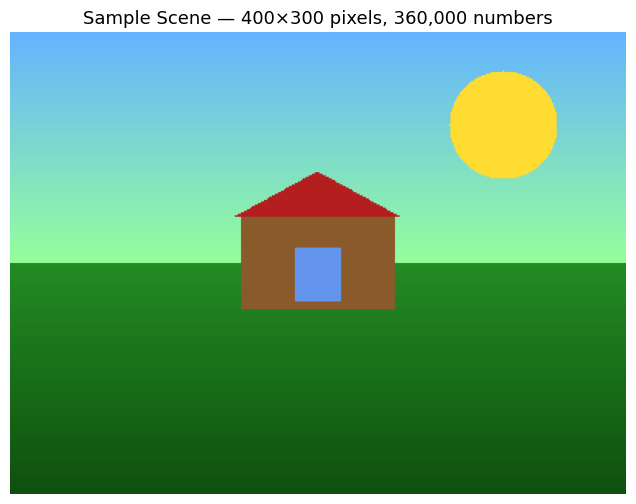

In [3]:
# ---- Create a sample image with interesting patterns ----
w, h = 400, 300
img_array = np.zeros((h, w, 3), dtype=np.uint8)

# Gradient sky (top half) — blue to light blue
for row in range(h // 2):
    blue_val = 255 - int(row / (h // 2) * 100)
    green_val = 180 + int(row / (h // 2) * 75)
    img_array[row, :] = [100 + int(row / (h//2) * 50), green_val, blue_val]

# Gradient ground (bottom half) — green to dark green
for row in range(h // 2, h):
    t = (row - h // 2) / (h // 2)
    img_array[row, :] = [34 - int(t * 20), 139 - int(t * 60), 34 - int(t * 20)]

# Add a yellow sun
cy, cx, r = 60, 320, 35
for y in range(max(0, cy-r), min(h, cy+r)):
    for x in range(max(0, cx-r), min(w, cx+r)):
        if (x - cx)**2 + (y - cy)**2 <= r**2:
            img_array[y, x] = [255, 220, 50]

# Add a brown house
img_array[120:180, 150:250] = [139, 90, 43]    # walls
img_array[140:175, 185:215] = [100, 149, 237]  # window (blue)

# Roof (triangle)
for row in range(90, 120):
    t = (row - 90) / 30  # 0 → 1
    left = int(200 - t * 55)
    right = int(200 + t * 55)
    img_array[row, max(0,left):min(w,right)] = [180, 30, 30]

sample_img = Image.fromarray(img_array)

# Save for later use
os.makedirs('images', exist_ok=True)
sample_img.save('images/sample_scene.png')
print(f"✅ Sample image saved to images/sample_scene.png")

# ---- Inspect the image ----
print(f"\n📋 Image Properties:")
print(f"   Size:       {sample_img.size} (width × height)")
print(f"   Mode:       {sample_img.mode} (RGB = 3 channels)")
print(f"   Format:     PNG")
print(f"   Total pixels: {sample_img.size[0] * sample_img.size[1]:,}")
print(f"   Total numbers: {sample_img.size[0] * sample_img.size[1] * 3:,} (pixels × 3 channels)")

# Convert to numpy and verify
arr = np.array(sample_img)
print(f"\n📊 As NumPy array:")
print(f"   Shape: {arr.shape} — (height, width, channels)")
print(f"   Min value: {arr.min()}, Max value: {arr.max()}")
print(f"   Memory: {arr.nbytes / 1024:.1f} KB")

# Display
plt.figure(figsize=(8, 6))
plt.imshow(sample_img)
plt.title(f'Sample Scene — {w}×{h} pixels, {w*h*3:,} numbers', fontsize=13)
plt.axis('off')
plt.show()

---
## Part 3: Pixel Manipulation — Edit Individual Pixels

Since images are arrays, you can **read and write** any pixel directly.  
This is exactly what neural networks do — they process these numbers!

🔍 Reading pixels from our image:
   ( 30, 200)          Sky: R=110, G=195, B=235
   ( 60, 320)          Sun: R=255, G=220, B= 50
   (150, 200)   House wall: R=100, G=149, B=237
   (155, 200)       Window: R=100, G=149, B=237
   (250, 200)       Ground: R= 21, G= 99, B= 21


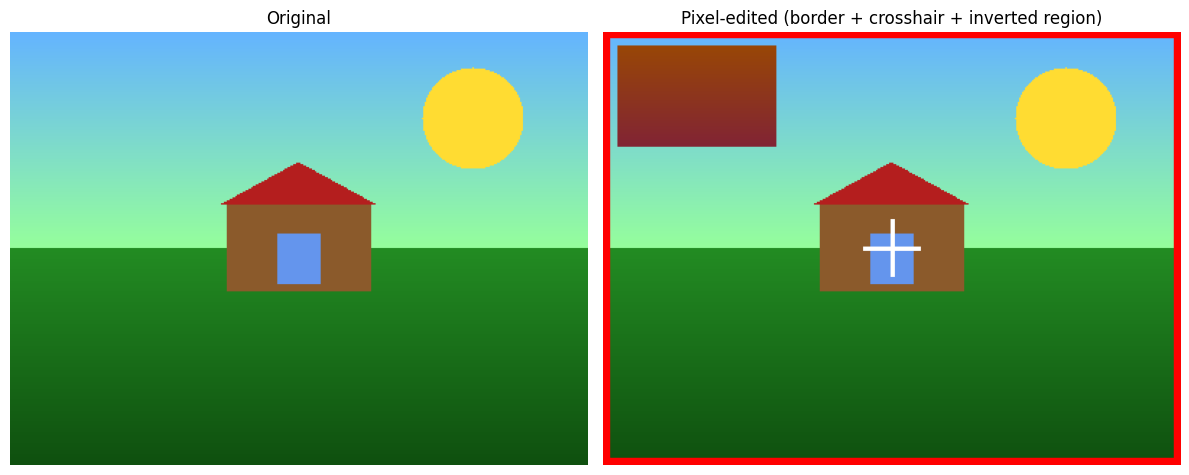


💡 KEY INSIGHT: Images = arrays. Edit array = edit image!
   This is what neural networks do — transform pixel arrays mathematically.


In [4]:
# ---- Read pixels ----
img = Image.open('images/sample_scene.png')
arr = np.array(img)

# Read specific pixels
print("🔍 Reading pixels from our image:")
locations = [(30, 200, 'Sky'), (60, 320, 'Sun'), (150, 200, 'House wall'),
             (155, 200, 'Window'), (250, 200, 'Ground')]

for y, x, name in locations:
    r, g, b = arr[y, x]
    print(f"   ({y:>3}, {x:>3}) {name:>12}: R={r:>3}, G={g:>3}, B={b:>3}")

# ---- Modify pixels ----
edited = arr.copy()

# Draw a red border (5 pixels wide)
border = 5
edited[:border, :] = [255, 0, 0]            # top
edited[-border:, :] = [255, 0, 0]           # bottom
edited[:, :border] = [255, 0, 0]            # left
edited[:, -border:] = [255, 0, 0]           # right

# Draw white crosshair at center
cy, cx = h // 2, w // 2
edited[cy-1:cy+2, cx-20:cx+20] = [255, 255, 255]  # horizontal
edited[cy-20:cy+20, cx-1:cx+2] = [255, 255, 255]  # vertical

# Invert a small region (turn colors upside down)
region = edited[10:80, 10:120].copy()
edited[10:80, 10:120] = 255 - region  # invert: 255 - pixel

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(edited)
axes[1].set_title('Pixel-edited (border + crosshair + inverted region)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

print(f"\n💡 KEY INSIGHT: Images = arrays. Edit array = edit image!")
print(f"   This is what neural networks do — transform pixel arrays mathematically.")

---
## Part 4: Color Channels — R, G, B Separated

Every pixel has 3 layers stacked together.  
Let's **pull them apart** to see what each channel looks like.

```
Full Image = Red Channel + Green Channel + Blue Channel
  (H,W,3)     (H,W)         (H,W)          (H,W)
```

CNNs process each channel separately in their first layers!

Full image shape:    (300, 400, 3)
Each channel shape:  (300, 400)

Channel ranges:
  Red:   min=15, max=255, mean=81.6
  Green: min=30, max=254, mean=156.4
  Blue:  min=15, max=255, mean=106.7


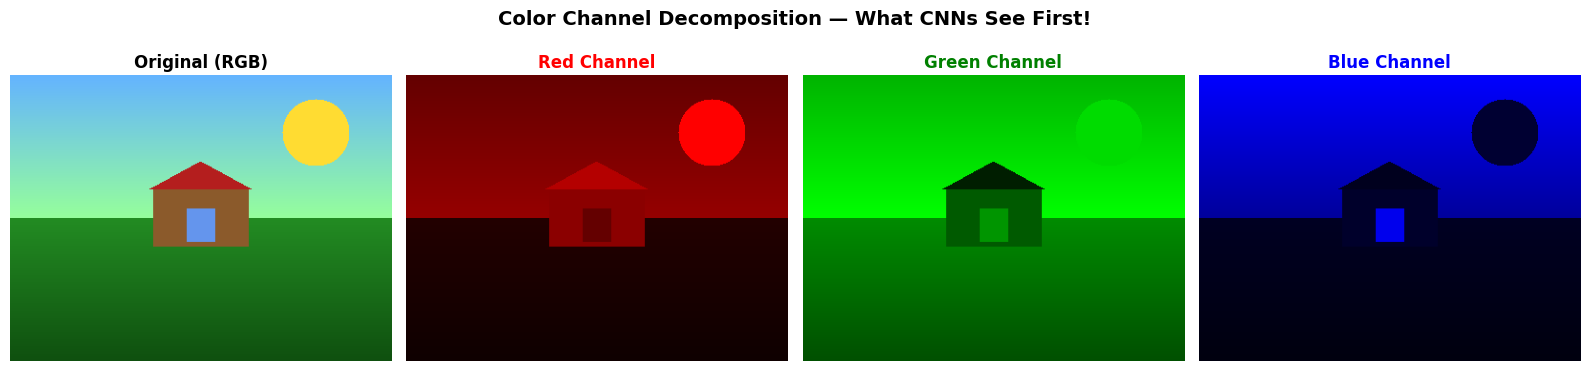

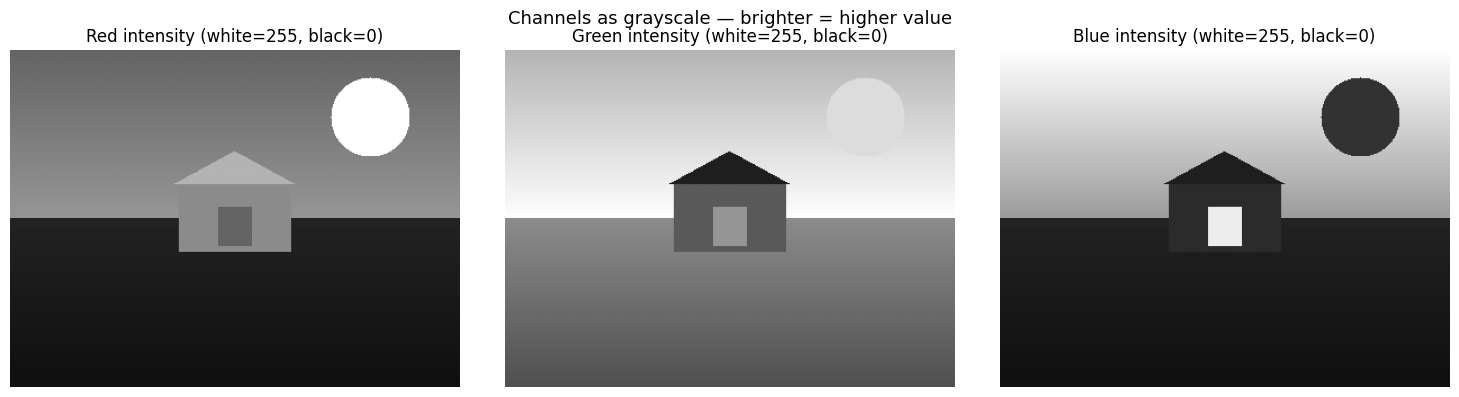


💡 Notice: The sun is bright in Red & Green (=yellow), dark in Blue.
   The sky is bright in Blue channel, dim in Red.
   CNNs learn to combine these channels to detect objects!


In [13]:
img = Image.open('images/sample_scene.png')
arr = np.array(img)

# Split into channels
red_channel   = arr[:, :, 0]   # just the R values
green_channel = arr[:, :, 1]   # just the G values
blue_channel  = arr[:, :, 2]   # just the B values

print(f"Full image shape:    {arr.shape}")
print(f"Each channel shape:  {red_channel.shape}")
print(f"\nChannel ranges:")
print(f"  Red:   min={red_channel.min()}, max={red_channel.max()}, mean={red_channel.mean():.1f}")
print(f"  Green: min={green_channel.min()}, max={green_channel.max()}, mean={green_channel.mean():.1f}")
print(f"  Blue:  min={blue_channel.min()}, max={blue_channel.max()}, mean={blue_channel.mean():.1f}")

# Visualize each channel
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(img)
axes[0].set_title('Original (RGB)', fontweight='bold')

# Show each channel in its own color
red_img = np.zeros_like(arr)
red_img[:, :, 0] = red_channel
axes[1].imshow(red_img)
axes[1].set_title('Red Channel', color='red', fontweight='bold')

green_img = np.zeros_like(arr)
green_img[:, :, 1] = green_channel
axes[2].imshow(green_img)
axes[2].set_title('Green Channel', color='green', fontweight='bold')

blue_img = np.zeros_like(arr)
blue_img[:, :, 2] = blue_channel
axes[3].imshow(blue_img)
axes[3].set_title('Blue Channel', color='blue', fontweight='bold')

for ax in axes:
    ax.axis('off')
plt.suptitle('Color Channel Decomposition — What CNNs See First!', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Also show as grayscale intensity maps
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, ch, name in zip(axes, [red_channel, green_channel, blue_channel], ['Red', 'Green', 'Blue']):
    ax.imshow(ch, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'{name} intensity (white=255, black=0)')
    ax.axis('off')
plt.suptitle('Channels as grayscale — brighter = higher value', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\n💡 Notice: The sun is bright in Red & Green (=yellow), dark in Blue.")
print(f"   The sky is bright in Blue channel, dim in Red.")
print(f"   CNNs learn to combine these channels to detect objects!")

---
## Part 5: Basic Transformations — Resize, Rotate, Crop, Flip

These are the **geometric operations** used in data augmentation for AI training.  
When training a CNN, we randomly flip/rotate/crop images to teach the model  
that a cat is still a cat even when flipped upside down!

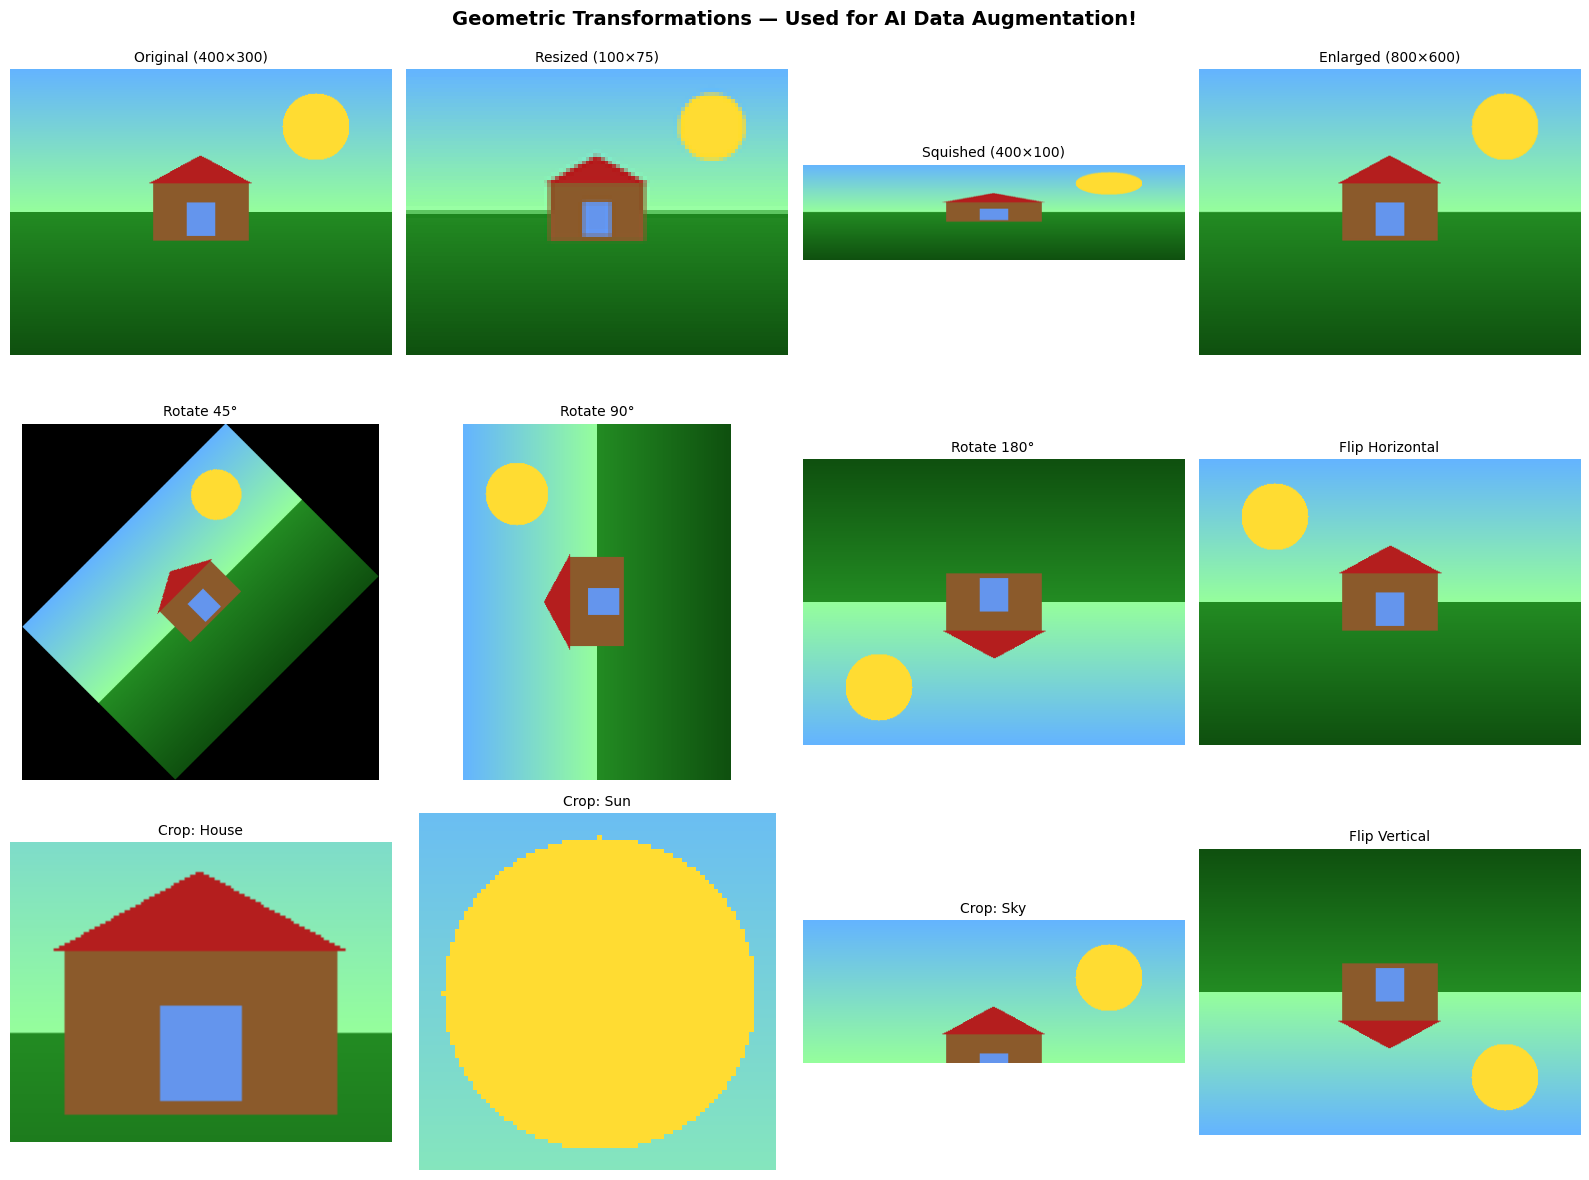

💡 WHY THIS MATTERS FOR AI:
   Data augmentation: flip + rotate + crop = 10× more training data
   Teach CNN that a cat is still a cat when flipped or cropped
   Resize: CNNs need fixed input size (e.g., 224×224)


In [7]:
img = Image.open('images/sample_scene.png')

# ---- RESIZE ----
small = img.resize((100, 75))           # shrink
large = img.resize((800, 600))          # enlarge
squished = img.resize((400, 100))       # distort aspect ratio

# ---- ROTATE ----
rot_45 = img.rotate(45, expand=True, fillcolor=(0, 0, 0))
rot_90 = img.rotate(90, expand=True)
rot_180 = img.rotate(180)

# ---- CROP ----
# crop box = (left, upper, right, lower)
house_crop = img.crop((130, 80, 270, 190))  # just the house
sun_crop = img.crop((280, 20, 360, 100))    # just the sun
sky_crop = img.crop((0, 0, 400, 150))       # upper half (sky)

# ---- FLIP ----
flip_h = img.transpose(Image.FLIP_LEFT_RIGHT)   # mirror
flip_v = img.transpose(Image.FLIP_TOP_BOTTOM)   # upside down

# Display all transformations
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

transforms = [
    (img, 'Original (400×300)'),
    (small, f'Resized ({small.size[0]}×{small.size[1]})'),
    (squished, f'Squished ({squished.size[0]}×{squished.size[1]})'),
    (large, f'Enlarged ({large.size[0]}×{large.size[1]})'),
    (rot_45, 'Rotate 45°'),
    (rot_90, 'Rotate 90°'),
    (rot_180, 'Rotate 180°'),
    (flip_h, 'Flip Horizontal'),
    (house_crop, 'Crop: House'),
    (sun_crop, 'Crop: Sun'),
    (sky_crop, 'Crop: Sky'),
    (flip_v, 'Flip Vertical'),
]

for ax, (im, title) in zip(axes.flat, transforms):
    ax.imshow(im)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.suptitle('Geometric Transformations — Used for AI Data Augmentation!',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"💡 WHY THIS MATTERS FOR AI:")
print(f"   Data augmentation: flip + rotate + crop = 10× more training data")
print(f"   Teach CNN that a cat is still a cat when flipped or cropped")
print(f"   Resize: CNNs need fixed input size (e.g., 224×224)")

---
## Part 6: Filters & Effects — Blur, Sharpen, Edge Detection

Filters work by sliding a small matrix (**kernel**) across the image.  
This is EXACTLY what a **convolutional layer** does in a CNN!

```
Blur kernel (3×3):       Edge detection kernel:
┌─────────────┐          ┌──────────────┐
│ 1/9  1/9  1/9│          │ -1  -1  -1  │
│ 1/9  1/9  1/9│     vs   │ -1   8  -1  │
│ 1/9  1/9  1/9│          │ -1  -1  -1  │
└─────────────┘          └──────────────┘
  Averages neighbors       Highlights differences
```

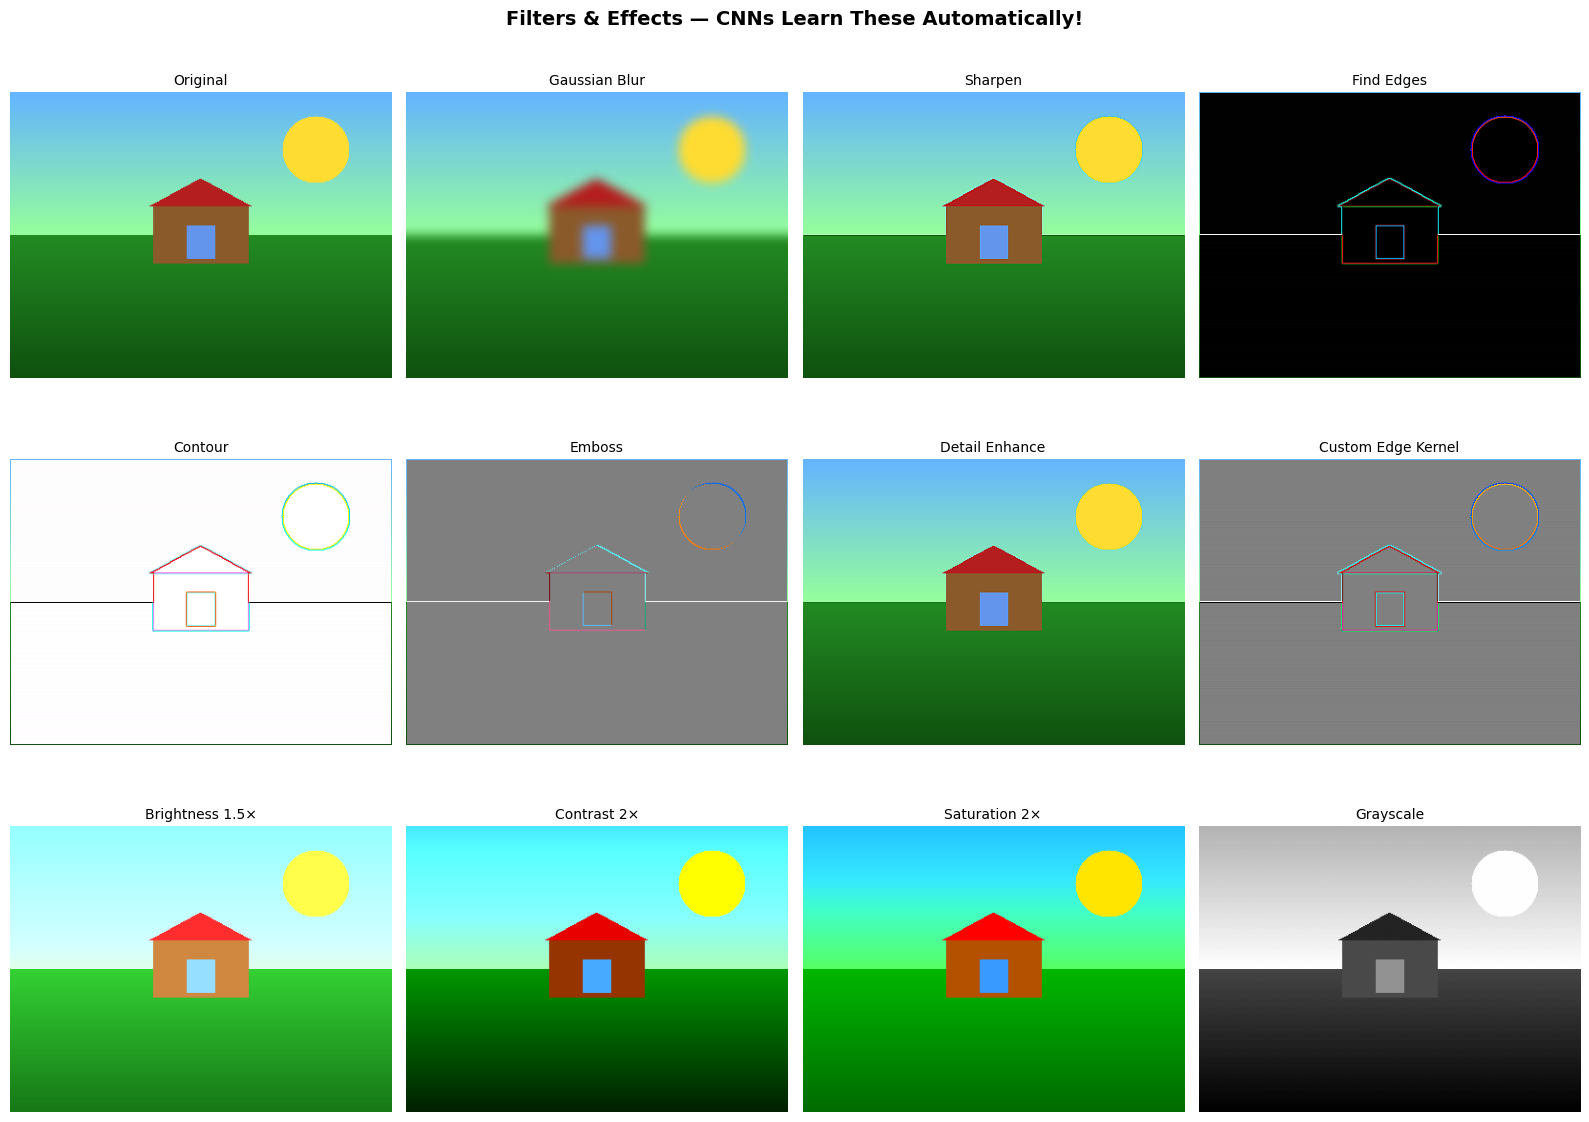

💡 KEY CONNECTION TO AI:
   A CNN's convolutional layer = sliding a kernel over the image
   BUT: CNN learns the BEST kernels automatically from data!
   Layer 1 learns edges, Layer 2 learns shapes, Layer 3 learns objects
   We manually defined the edge kernel above — CNN discovers it itself!


In [6]:
img = Image.open('images/sample_scene.png')

# ---- Built-in Pillow Filters ----
blurred      = img.filter(ImageFilter.GaussianBlur(radius=5))
sharpened    = img.filter(ImageFilter.SHARPEN)
edges        = img.filter(ImageFilter.FIND_EDGES)
contour      = img.filter(ImageFilter.CONTOUR)
emboss       = img.filter(ImageFilter.EMBOSS)
detail       = img.filter(ImageFilter.DETAIL)

# ---- Custom kernel (edge detection) ----
custom_kernel = ImageFilter.Kernel(
    size=(3, 3),
    kernel=[-1, -1, -1,
            -1,  8, -1,
            -1, -1, -1],
    scale=1,
    offset=128  # shift to gray background
)
custom_edges = img.filter(custom_kernel)

# ---- Color adjustments ----
bright   = ImageEnhance.Brightness(img).enhance(1.5)   # 1.5× brighter
contrast = ImageEnhance.Contrast(img).enhance(2.0)     # 2× contrast
saturated = ImageEnhance.Color(img).enhance(2.0)       # 2× color
grayscale = img.convert('L')                            # remove color

# Display filters
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

filters = [
    (img, 'Original'),
    (blurred, 'Gaussian Blur'),
    (sharpened, 'Sharpen'),
    (edges, 'Find Edges'),
    (contour, 'Contour'),
    (emboss, 'Emboss'),
    (detail, 'Detail Enhance'),
    (custom_edges, 'Custom Edge Kernel'),
    (bright, 'Brightness 1.5×'),
    (contrast, 'Contrast 2×'),
    (saturated, 'Saturation 2×'),
    (grayscale, 'Grayscale'),
]

for ax, (im, title) in zip(axes.flat, filters):
    if im.mode == 'L':
        ax.imshow(im, cmap='gray')
    else:
        ax.imshow(im)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.suptitle('Filters & Effects — CNNs Learn These Automatically!',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"💡 KEY CONNECTION TO AI:")
print(f"   A CNN's convolutional layer = sliding a kernel over the image")
print(f"   BUT: CNN learns the BEST kernels automatically from data!")
print(f"   Layer 1 learns edges, Layer 2 learns shapes, Layer 3 learns objects")
print(f"   We manually defined the edge kernel above — CNN discovers it itself!")

---
## Part 7: Drawing on Images — Text, Shapes, Overlays

Useful for adding labels, bounding boxes (object detection),  
and building image editing tools.

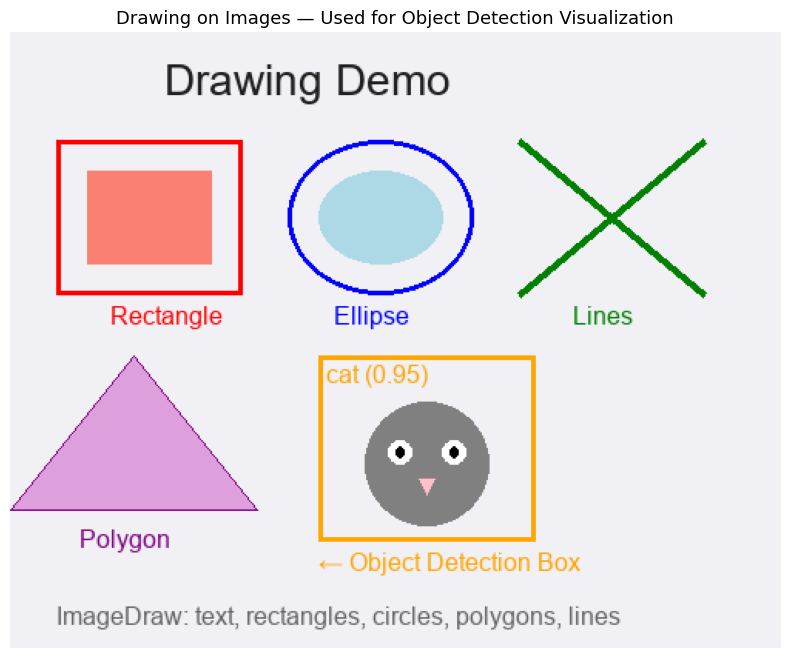

💡 Object detection models (YOLO, R-CNN) output bounding boxes
   like the orange rectangle above — drawn on the image for visualization.


In [8]:
# Create a fresh canvas
canvas = Image.new('RGB', (500, 400), color=(240, 240, 245))
draw = ImageDraw.Draw(canvas)

# Try to load a nice font, fall back to default
try:
    font_large = ImageFont.truetype("arial.ttf", 28)
    font_small = ImageFont.truetype("arial.ttf", 16)
except:
    font_large = ImageFont.load_default()
    font_small = ImageFont.load_default()

# Title
draw.text((100, 15), "Drawing Demo", fill=(30, 30, 30), font=font_large)

# Shapes
draw.rectangle([30, 70, 150, 170], outline='red', width=3)         # rectangle
draw.rectangle([50, 90, 130, 150], fill='salmon')                   # filled rect
draw.ellipse([180, 70, 300, 170], outline='blue', width=3)         # circle
draw.ellipse([200, 90, 280, 150], fill='lightblue')                # filled circle
draw.line([(330, 70), (450, 170)], fill='green', width=4)          # line
draw.line([(330, 170), (450, 70)], fill='green', width=4)          # X shape

draw.text((65, 175), "Rectangle", fill='red', font=font_small)
draw.text((210, 175), "Ellipse", fill='blue', font=font_small)
draw.text((365, 175), "Lines", fill='green', font=font_small)

# Polygon (triangle)
draw.polygon([(80, 210), (160, 310), (0, 310)], outline='purple', fill='plum')
draw.text((45, 320), "Polygon", fill='purple', font=font_small)

# Bounding box simulation (like object detection)
draw.rectangle([200, 210, 340, 330], outline='orange', width=3)
draw.text((205, 213), "cat (0.95)", fill='orange', font=font_small)
# Draw a simple cat face inside
draw.ellipse([230, 240, 310, 320], fill='gray')       # head
draw.ellipse([245, 265, 260, 280], fill='white')       # left eye
draw.ellipse([280, 265, 295, 280], fill='white')       # right eye
draw.ellipse([250, 269, 255, 276], fill='black')       # pupil
draw.ellipse([285, 269, 290, 276], fill='black')       # pupil
draw.polygon([(265, 290), (270, 300), (275, 290)], fill='pink')  # nose

draw.text((200, 335), "← Object Detection Box", fill='orange', font=font_small)

# Info text
draw.text((30, 370), "ImageDraw: text, rectangles, circles, polygons, lines",
          fill=(100, 100, 100), font=font_small)

plt.figure(figsize=(10, 8))
plt.imshow(canvas)
plt.title('Drawing on Images — Used for Object Detection Visualization', fontsize=13)
plt.axis('off')
plt.show()

print(f"💡 Object detection models (YOLO, R-CNN) output bounding boxes")
print(f"   like the orange rectangle above — drawn on the image for visualization.")

---
## Part 8: Mini Image Editor — All Tools Combined 🛠️

Let's build a function that applies a **chain of edits** —  
this is the same concept as an **AI image editing pipeline**!

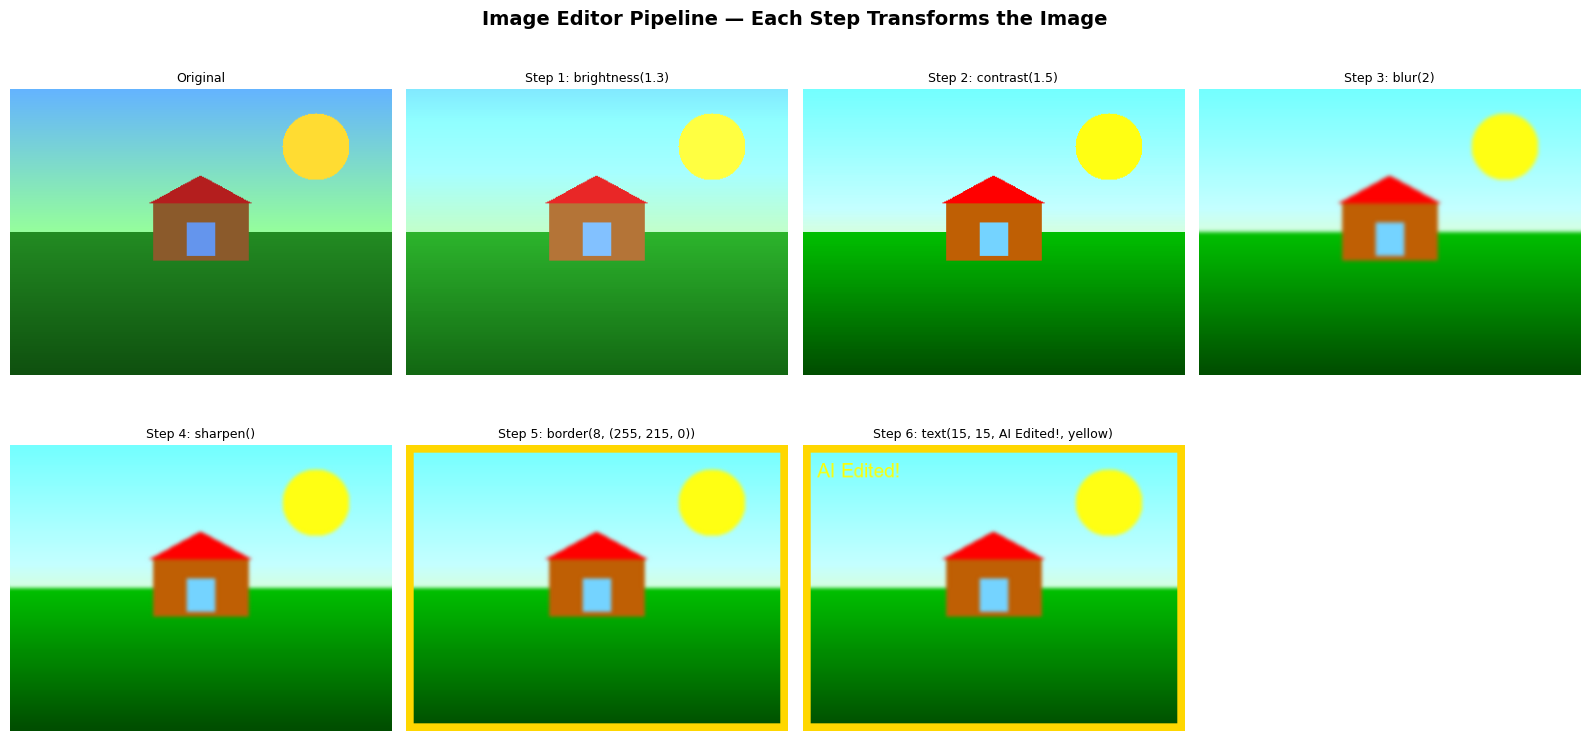

✅ Edited image saved to images/edited_scene.png


In [10]:
def image_editor(image_path, operations):
    """
    Mini Image Editor — apply a chain of operations.
    
    Supported operations:
      resize(w, h)     — resize to w×h
      rotate(degrees)  — rotate by degrees
      crop(l,t,r,b)    — crop region
      flip(h/v)        — flip horizontal or vertical
      blur(radius)     — gaussian blur
      sharpen()        — sharpen
      edges()          — find edges
      grayscale()      — convert to grayscale
      brightness(f)    — adjust brightness (1.0 = normal)
      contrast(f)      — adjust contrast
      border(w, color) — add border
      text(x,y,t,c)    — draw text at position
    """
    img = Image.open(image_path) if isinstance(image_path, str) else image_path.copy()
    history = [('Original', img.copy())]
    
    for op in operations:
        name = op[0]
        args = op[1:]
        
        if name == 'resize':
            img = img.resize((args[0], args[1]))
        elif name == 'rotate':
            img = img.rotate(args[0], expand=True, fillcolor=(0,0,0))
        elif name == 'crop':
            img = img.crop(args[0])
        elif name == 'flip':
            if args[0] == 'h':
                img = img.transpose(Image.FLIP_LEFT_RIGHT)
            else:
                img = img.transpose(Image.FLIP_TOP_BOTTOM)
        elif name == 'blur':
            img = img.filter(ImageFilter.GaussianBlur(radius=args[0]))
        elif name == 'sharpen':
            img = img.filter(ImageFilter.SHARPEN)
        elif name == 'edges':
            img = img.filter(ImageFilter.FIND_EDGES)
        elif name == 'grayscale':
            img = img.convert('L')
        elif name == 'brightness':
            img = ImageEnhance.Brightness(img).enhance(args[0])
        elif name == 'contrast':
            img = ImageEnhance.Contrast(img).enhance(args[0])
        elif name == 'border':
            arr = np.array(img)
            bw = args[0]
            color = args[1] if len(args) > 1 else (255, 0, 0)
            if len(arr.shape) == 2:  # grayscale
                arr[:bw, :] = 255; arr[-bw:, :] = 255
                arr[:, :bw] = 255; arr[:, -bw:] = 255
            else:
                arr[:bw, :] = color; arr[-bw:, :] = color
                arr[:, :bw] = color; arr[:, -bw:] = color
            img = Image.fromarray(arr)
        elif name == 'text':
            if img.mode == 'L':
                img = img.convert('RGB')
            d = ImageDraw.Draw(img)
            try:
                font = ImageFont.truetype("arial.ttf", 20)
            except:
                font = ImageFont.load_default()
            d.text((args[0], args[1]), args[2],
                   fill=args[3] if len(args) > 3 else 'white', font=font)
        
        label = f"{name}({', '.join(str(a) for a in args)})"
        history.append((label, img.copy() if img.mode != 'L' else img.convert('RGB').copy()))
    
    return img, history


# ---- Demo: Apply a chain of edits ----
operations = [
    ('brightness', 1.3),
    ('contrast', 1.5),
    ('blur', 2),
    ('sharpen',),
    ('border', 8, (255, 215, 0)),
    ('text', 15, 15, 'AI Edited!', 'yellow'),
]

result, history = image_editor('images/sample_scene.png', operations)

# Show the editing pipeline
n = len(history)
cols = min(4, n)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
if rows == 1:
    axes = [axes] if cols == 1 else axes
    axes_flat = axes if isinstance(axes, list) else list(axes)
else:
    axes_flat = axes.flat

all_axes = list(axes_flat) if hasattr(axes_flat, '__iter__') else [axes_flat]
for i, (label, im) in enumerate(history):
    all_axes[i].imshow(im)
    step_label = f'Step {i}: {label}' if i > 0 else label
    all_axes[i].set_title(step_label, fontsize=9)
    all_axes[i].axis('off')

# Hide unused axes
for j in range(n, len(all_axes)):
    all_axes[j].axis('off')
    all_axes[j].set_visible(False)

plt.suptitle('Image Editor Pipeline — Each Step Transforms the Image',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Save final result
result_rgb = result if result.mode == 'RGB' else result.convert('RGB')
result_rgb.save('images/edited_scene.png')
print(f"✅ Edited image saved to images/edited_scene.png")

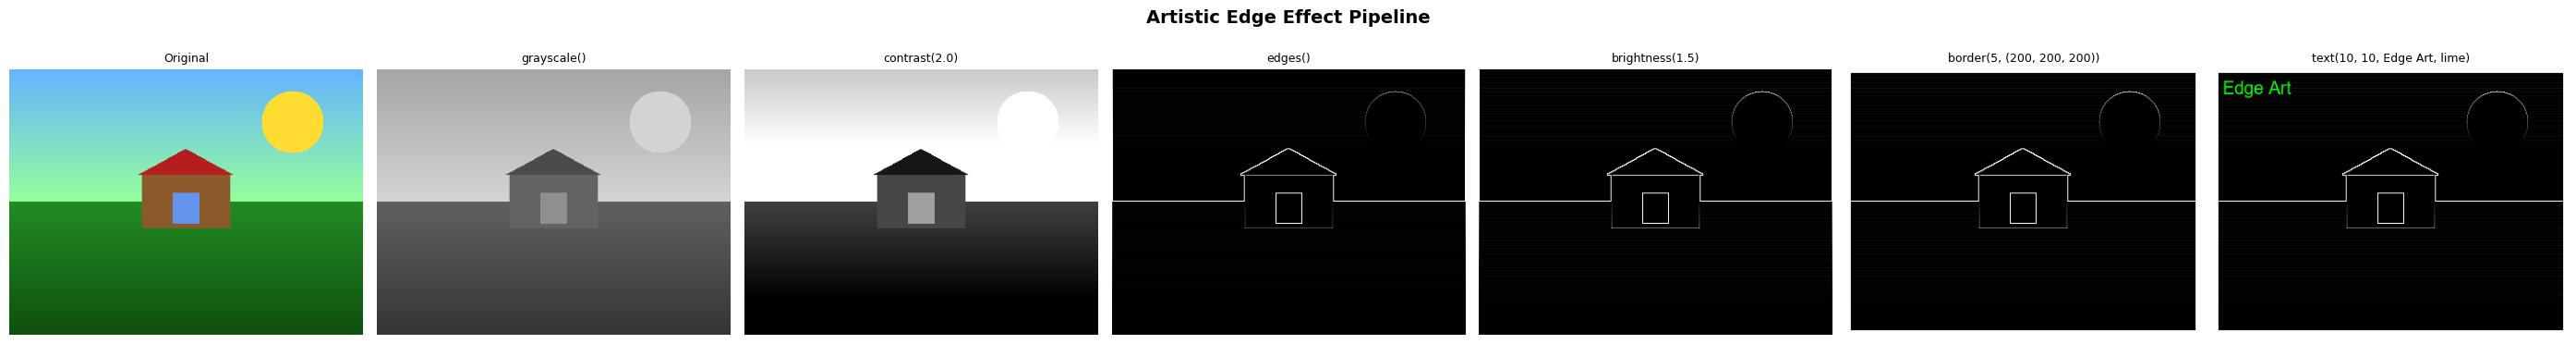


💡 This pipeline concept is how AI image editors work:
   User says 'make it look like a sketch'
   AI picks: grayscale → contrast → edge detection
   Same chain-of-operations idea!


In [11]:
# ---- Another demo: artistic edge effect ----
art_ops = [
    ('grayscale',),
    ('contrast', 2.0),
    ('edges',),
    ('brightness', 1.5),
    ('border', 5, (200, 200, 200)),
    ('text', 10, 10, 'Edge Art', 'lime'),
]

result2, history2 = image_editor('images/sample_scene.png', art_ops)

fig, axes = plt.subplots(1, len(history2), figsize=(4 * len(history2), 4))
for ax, (label, im) in zip(axes, history2):
    ax.imshow(im)
    ax.set_title(label, fontsize=9)
    ax.axis('off')
plt.suptitle('Artistic Edge Effect Pipeline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n💡 This pipeline concept is how AI image editors work:")
print(f"   User says 'make it look like a sketch'")
print(f"   AI picks: grayscale → contrast → edge detection")
print(f"   Same chain-of-operations idea!")

---
## Part 9: How CNNs See Your Image — The Bridge to Step 19

Let's connect everything to what's coming next: **Convolutional Neural Networks**.

Image as tensor: torch.Size([1, 1, 300, 400])
  Batch size: 1
  Channels:   1 (grayscale = 1)
  Height:     300
  Width:      400


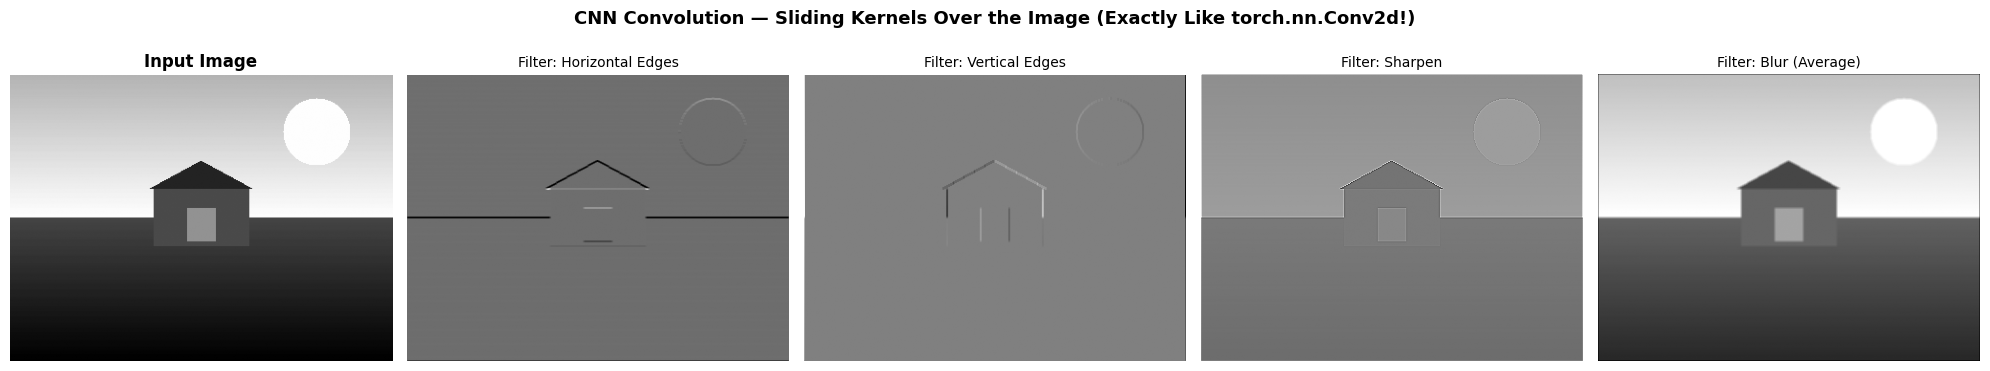


⭐ THIS IS WHAT A CNN DOES!
   Layer 1: Learn simple filters (edges, blurs) — like the ones above
   Layer 2: Combine edges → detect shapes (circles, rectangles)
   Layer 3: Combine shapes → detect parts (eyes, wheels, roofs)
   Layer 4+: Combine parts → detect objects (cats, cars, houses)

   The CNN LEARNS which kernels are best — we don't tell it!
   F.conv2d() above = exactly torch.nn.Conv2d in a real CNN.


In [12]:
import torch
import torch.nn.functional as F

img = Image.open('images/sample_scene.png').convert('L')  # grayscale
img_tensor = torch.tensor(np.array(img), dtype=torch.float32)
img_tensor = img_tensor.unsqueeze(0).unsqueeze(0)  # (1, 1, H, W) — batch, channel

print(f"Image as tensor: {img_tensor.shape}")
print(f"  Batch size: {img_tensor.shape[0]}")
print(f"  Channels:   {img_tensor.shape[1]} (grayscale = 1)")
print(f"  Height:     {img_tensor.shape[2]}")
print(f"  Width:      {img_tensor.shape[3]}")

# Define 4 different kernels (filters) — like a CNN's first layer
kernels = {
    'Horizontal Edges': [[-1, -1, -1],
                         [ 0,  0,  0],
                         [ 1,  1,  1]],

    'Vertical Edges':   [[-1,  0,  1],
                         [-1,  0,  1],
                         [-1,  0,  1]],

    'Sharpen':          [[ 0, -1,  0],
                         [-1,  5, -1],
                         [ 0, -1,  0]],

    'Blur (Average)':   [[1/9, 1/9, 1/9],
                         [1/9, 1/9, 1/9],
                         [1/9, 1/9, 1/9]],
}

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Input Image', fontweight='bold')
axes[0].axis('off')

for i, (name, kernel) in enumerate(kernels.items()):
    # Create convolution filter (same as CNN layer!)
    k = torch.tensor([[kernel]], dtype=torch.float32)  # (1,1,3,3)
    output = F.conv2d(img_tensor, k, padding=1)
    output_np = output.squeeze().numpy()
    
    axes[i+1].imshow(output_np, cmap='gray')
    axes[i+1].set_title(f'Filter: {name}', fontsize=10)
    axes[i+1].axis('off')

plt.suptitle('CNN Convolution — Sliding Kernels Over the Image (Exactly Like torch.nn.Conv2d!)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n⭐ THIS IS WHAT A CNN DOES!")
print(f"   Layer 1: Learn simple filters (edges, blurs) — like the ones above")
print(f"   Layer 2: Combine edges → detect shapes (circles, rectangles)")
print(f"   Layer 3: Combine shapes → detect parts (eyes, wheels, roofs)")
print(f"   Layer 4+: Combine parts → detect objects (cats, cars, houses)")
print(f"\n   The CNN LEARNS which kernels are best — we don't tell it!")
print(f"   F.conv2d() above = exactly torch.nn.Conv2d in a real CNN.")

---
## ✅ Summary — What You Learned

| Concept | What You Built | AI Connection |
|---------|---------------|---------------|
| **Pixels** | Created images from raw numbers | Neural nets process these arrays |
| **RGB Channels** | Split & visualized R, G, B | CNN input channels |
| **Resize/Crop/Flip** | Geometric transformations | Data augmentation for training |
| **Filters (Kernels)** | Blur, sharpen, edge detection | CNN convolutional layers |
| **Drawing** | Text, shapes, bounding boxes | Object detection visualization |
| **Image Editor** | Chain of operations pipeline | AI editing workflows |
| **Conv2d** | Applied filters with PyTorch | Exact same as `nn.Conv2d` |

### Key Takeaway

```
Image = array of numbers (H × W × 3)
Filter = small matrix (3 × 3) slid over the image
CNN = learns the BEST filters automatically from data
```

### Roadmap

| Step | Topic | Status |
|------|-------|--------|
| 1–13 | RAG Pipeline (Naive → Agentic) | ✅ Done |
| 14 | Build GPT From Scratch | ✅ Done |
| **18** | **Image Basics in Python (this notebook!)** | ✅ Done |
| 19 | CNNs — Image Classification | ⭕ Next |

---
*Next up: Step 19 — Build a CNN that classifies images (CIFAR-10)*